In [84]:
import xarray as xr
from tqdm import tqdm
import numpy as np
from scipy.signal import butter, lfilter, freqz, filtfilt
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import scipy.stats as stats
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from xmca.xarray import xMCA  # xarray

In [6]:
def butter_lowpass(cutoff, fs, order=5):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a
def butter_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data,axis=1)
    return y
def butter_bandpass(lowcut, highcut, fs, order=5):
    return butter(order, [lowcut, highcut], fs=fs, btype='band')
def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data,axis=0)
    return y

In [3]:
#loading in the seasonal rainfall data from the LME
precip_jja_full = xr.open_dataset('/vortexfs1/home/swang/Walker/lme_precip_global_jja_0324.nc')
precip_djf_full = xr.open_dataset('/vortexfs1/home/swang/Walker/lme_precip_global_djf_0324.nc')

#extracting and scaling the rainfall data
precip_jja = precip_jja_full['__xarray_dataarray_variable__'] *2.628e9
precip_djf = precip_djf_full['__xarray_dataarray_variable__'] *2.628e9

In [8]:
#loop through each ensemble member and conduct EOF analysis, only focusing on land-rainfall
lme_pcs1 = []
lme_eofs1 = []

lme_pcs2 = []
lme_eofs2 = []

p_sub_jja = precip_jja.sel(lat=slice(5,40),lon=slice(90,140)) #boreal summer (Asian Monsoon)
p_sub_djf = precip_djf.sel(lat=slice(-25,5),lon=slice(90,140)) #austral summer (Australian Monsoon)

#apply a 25-year lowpass filter on data
p_sub_jja_smooth = p_sub_jja.copy()
p_sub_djf_smooth = p_sub_djf.copy()
p_sub_jja_smooth.values = butter_lowpass_filter(p_sub_jja,1/25,1)
p_sub_djf_smooth.values = butter_lowpass_filter(p_sub_djf,1/25,1)

In [57]:
#Using EOF analysis to extract the 1st two leading PCs/EOFs of both hemispheres

coslat1 = np.cos(np.deg2rad(p_sub_jja_smooth.lat.values))
wgts1 = np.sqrt(coslat1)[..., np.newaxis]

coslat2 = np.cos(np.deg2rad(p_sub_djf_smooth.lat.values))
wgts2 = np.sqrt(coslat2)[..., np.newaxis]

jja_pcs_list = []
jja_eofs_list = []
djf_pcs_list = []
djf_eofs_list = []

#loop through and calculate EOF analysis, truncate the first 25 years and last 100 years of the LME.
#first 25 years are removed to minimize filtering artifacts. last 100 years are removed to focus on pre-industrial variability
#I use the xMCA package to calculate these EOF/PCs. When only one dataset is given, MCA collapses into PCA.

for i in tqdm(range(13)):
    mca1 = xMCA(p_sub_jja_smooth[i,25:-100,:,:])
    mca1.normalize()
    mca1.apply_coslat()
    mca1.solve()
    jja_pcs_list.append(mca1.pcs(n=2))
    jja_eofs_list.append(mca1.eofs(n=2))
    
    mca2 = xMCA(p_sub_djf_smooth[i,25:-100,:,:])
    mca2.normalize()
    mca2.apply_coslat()
    mca2.solve()
    djf_pcs_list.append(mca2.pcs(n=2))
    djf_eofs_list.append(mca2.eofs(n=2))

In [65]:
jja_pcs_ar = np.zeros((13,jja_pcs_list[0]['left'].sel(mode=2).shape[0]))
djf_pcs_ar = np.zeros((13,djf_pcs_list[0]['left'].sel(mode=1).shape[0]))

jja_eofs_ar = np.zeros((13,jja_eofs_list[0]['left'].sel(mode=2).shape[0],jja_eofs_list[0]['left'].sel(mode=2).shape[1]))
djf_eofs_ar = np.zeros((13,djf_eofs_list[0]['left'].sel(mode=1).shape[0],djf_eofs_list[0]['left'].sel(mode=1).shape[1]))

In [68]:
for i in range(13):
    jja_pcs_ar[i,:] = jja_pcs_list[i]['left'].sel(mode=2)
    djf_pcs_ar[i,:] = djf_pcs_list[i]['left'].sel(mode=1)
    
    jja_eofs_ar[i,:,:] = jja_eofs_list[i]['left'].sel(mode=2)
    djf_eofs_ar[i,:,:] = djf_eofs_list[i]['left'].sel(mode=1)

In [69]:
#because the sign of EOF is arbitrary, we go through each EM and set the sign of our output to be consistent

jja_eofs_flip = np.zeros((jja_eofs_ar.shape))
djf_eofs_flip = np.zeros((djf_eofs_ar.shape))
jja_pcs_flip = np.zeros((jja_pcs_ar.shape))
djf_pcs_flip = np.zeros((djf_pcs_ar.shape))

for i in range(13):
    jja_temp = jja_eofs_ar[i,:,:].flatten()
    jja1 = jja_eofs_ar[0,:,:].flatten() #ensemble member 1 is the benchmark
    if stats.pearsonr(jja_temp,jja1)[0] < 0: #set JJA EOF-2 to be negative
        jja_eofs_flip[i,:,:] = 1 * jja_eofs_ar[i,:,:]
        jja_pcs_flip[i,:] = 1 * jja_pcs_ar[i,:]
    else:
        jja_eofs_flip[i,:,:] = -1 * jja_eofs_ar[i,:,:]
        jja_pcs_flip[i,:] = -1 * jja_pcs_ar[i,:]

for i in range(13):
    djf_temp = djf_eofs_ar[i,:,:].flatten()
    djf1 = djf_eofs_ar[0,:,:].flatten() #ensemble member 1 is the benchmark
    if stats.pearsonr(djf_temp,djf1)[0] < 0: #set DJF EOF-1 to be positive
        djf_eofs_flip[i,:,:] = -1 * djf_eofs_ar[i,:,:]
        djf_pcs_flip[i,:] = -1 * djf_pcs_ar[i,:]
    else:
        djf_eofs_flip[i,:,:] = 1 * djf_eofs_ar[i,:,:]
        djf_pcs_flip[i,:] = 1 * djf_pcs_ar[i,:]

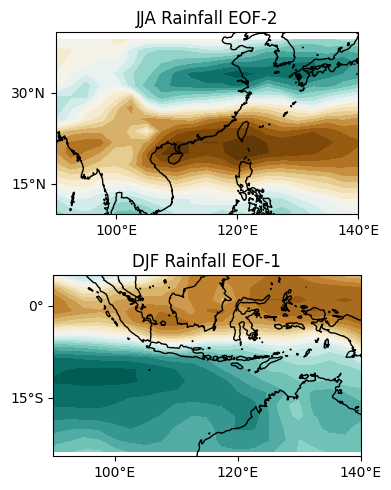

In [76]:
#visualize the spatial patterns of EOF analysis to be sure they 

plt.style.use('default') # Adjust style (optional)
fig = plt.figure(figsize=(7,5))
ax = plt.subplot(2,1,1,projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([90, 140, 10, 40], crs=ccrs.PlateCarree())
h = ax.contourf(p_sub_jja.lon,p_sub_jja.lat,np.nanmedian(jja_eofs_flip[:,:,:],axis=0),cmap='BrBG',transform=ccrs.PlateCarree(),levels=20,vmin=-.1,vmax=.1)
ax.coastlines(alpha=1)
ax.set_title('JJA Rainfall EOF-2')
ax.set_xticks([100,120,140], crs=ccrs.PlateCarree())
ax.set_yticks([15,30], crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)


ax = plt.subplot(2,1,2,projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([90, 140, -24.5, 5], crs=ccrs.PlateCarree())
h = ax.contourf(p_sub_djf.lon,p_sub_djf.lat,np.nanmedian(djf_eofs_flip[:,:,:],axis=0),cmap='BrBG',transform=ccrs.PlateCarree(),levels=20,vmin=-.1,vmax=.1)
ax.coastlines(alpha=1)
ax.set_title('DJF Rainfall EOF-1')
ax.set_xticks([100,120,140], crs=ccrs.PlateCarree())
ax.set_yticks([-15,0], crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
#fig.colorbar(h,label='EOF Loadings',ticks=[-0.05,0,0.05])
fig.tight_layout()

Text(0, 0.5, 'Rainbelt width')

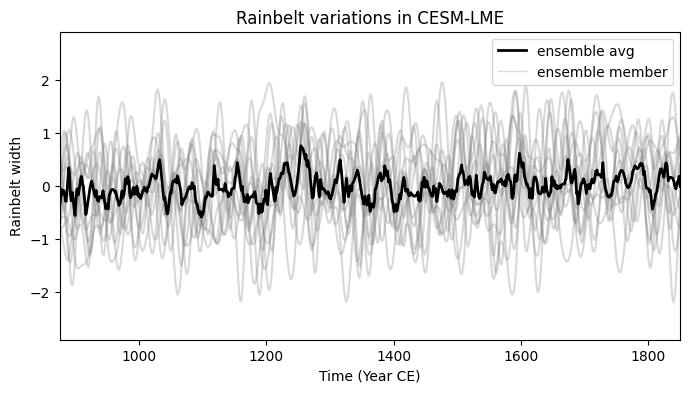

In [79]:
#The TRB index is constructed to maximize the simultaneous increase of rainfall at subtropical latitudes in both hemispheres
#Here we simply build it as the average of PCs which correspond to the spatial rainfall patterns above

trb_index = np.mean([djf_pcs_flip,jja_pcs_flip],axis=0)
trb_time = p_sub_jja.time.dt.year.values[25:-100]

plt.style.use('default') # Adjust style (optional)
fig = plt.figure(figsize=(8,4))
ax = plt.subplot(1,1,1)
for i in range(13):
    ax.plot(trb_time,trb_index[i,:],color='gray',linewidth=1.5,alpha=0.3)
ax.plot(trb_time,np.median(trb_index,axis=0),color='black',linewidth=2,label='ensemble avg')
ax.plot(np.nan,np.nan,color='gray',linewidth=1,alpha=0.3,label='ensemble member')
ax.legend()
ax.set_ylim(-2.9,2.9)
ax.set_xlim(875,1850)
ax.set_title('Rainbelt variations in CESM-LME')
ax.set_xlabel('Time (Year CE)')
ax.set_ylabel('Rainbelt width')

In [82]:
trb_index_da = xr.DataArray(data=trb_index,
                            dims=("ens", "time"),
                            coords={"ens": np.arange(1,14), "time": trb_time})

In [85]:
#trb_index_da.to_netcdf('trb_index_lme.nc')